# Part 1: Load and Explore the Dataset

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape :", x_test.shape)
print("y_test shape :", y_test.shape)

class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]
print("Number of classes:", len(class_names))

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape : (10000, 28, 28)
y_test shape : (10000,)
Number of classes: 10


Why is normalization required for image data?

Normalization scales pixel values from the range 0–255 to 0–1 by dividing each pixel value by 255. This ensures that all input features are on a similar scale, which helps the neural network train more efficiently. Normalization improves gradient flow during backpropagation, speeds up convergence, and leads to more stable training performance. It also helps reduce issues such as exploding or vanishing gradients.

Why do CNNs require reshaped image inputs?

CNNs require input data in the format (batch_size, height, width, channels). The Fashion-MNIST dataset is initially loaded with shape (60000, 28, 28), which contains only the image height and width dimensions. Since the images are grayscale, a channel dimension must be added, resulting in the shape (60000, 28, 28, 1). This allows the convolutional layers to correctly process the image data and apply filters across the spatial dimensions of the image.

##Display One Sample From Each Class

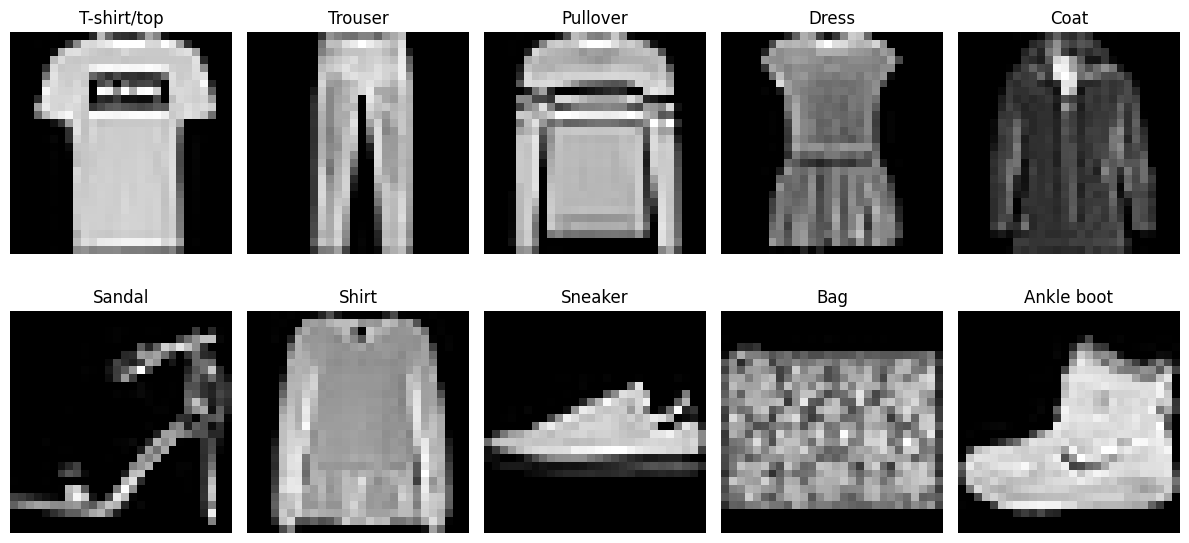

In [ ]:
plt.figure(figsize=(12,6))

for i in range(10):


    plt.subplot(2,5,i+1)
    plt.imshow(x_train[idx], cmap='gray')
    plt.title(class_names[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

Normalize the pixel values so that all input are on a similar scale

In [ ]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [ ]:
print(x_train.min())
print(x_train.max())

0.0
1.0


Reshaping the images

In [ ]:
print(x_train.shape)

(60000, 28, 28)


In [ ]:
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

In [ ]:
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)



Why is normalization required for image data?

Normalization scales pixel values to a common range (0–1), which improves convergence speed, numerical stability, and overall model performance during training.

Why do CNNs require reshaped image inputs?

CNN layers operate on spatial image data and expect an explicit channel dimension. Even grayscale images must include a channel dimension of 1.

#Part 2: Build and Train a Shallow CNN

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

Building the model

In [ ]:
model = Sequential([

    Conv2D(32, (3,3), activation='relu',
           input_shape=(28,28,1)),

    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),

    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),

    Dropout(0.3),

    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


optimizing weights after backpropogation computes gradients

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Training the model

In [ ]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_data=(x_test, y_test)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 66s 34ms/step - accuracy: 0.8251 - loss: 0.4866 - val_accuracy: 0.8756 - val_loss: 0.3461
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 34ms/step - accuracy: 0.8819 - loss: 0.3238 - val_accuracy: 0.8894 - val_loss: 0.2997
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 79s 32ms/step - accuracy: 0.8979 - loss: 0.2804 - val_accuracy: 0.8902 - val_loss: 0.2895
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 32ms/step - accuracy: 0.9066 - loss: 0.2538 - val_accuracy: 0.9052 - val_loss: 0.2666
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 87s 34ms/step - accuracy: 0.9153 - loss: 0.2299 - val_accuracy: 0.9071 - val_loss: 0.2536
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 61s 33ms/step - accuracy: 0.9214 - loss: 0.2103 - val_accuracy: 0.9100 - val_loss: 0.2517
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 33ms/step - accuracy: 0.9273 - loss: 0.1956 - val_accuracy: 0.9110 - val_loss: 0.2487
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 63s 34ms/step - accuracy: 0.9323 -

Print the accuracy

In [ ]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test
)

print(test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9151 - loss: 0.2612
0.9150999784469604


Visualizing the training accuracy and validation accuracy

> Add blockquote



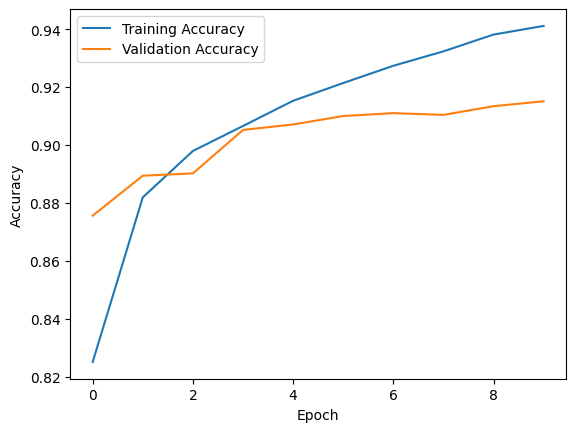

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],
         label='Training Accuracy')

plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

Visualizing training loss and validation loss

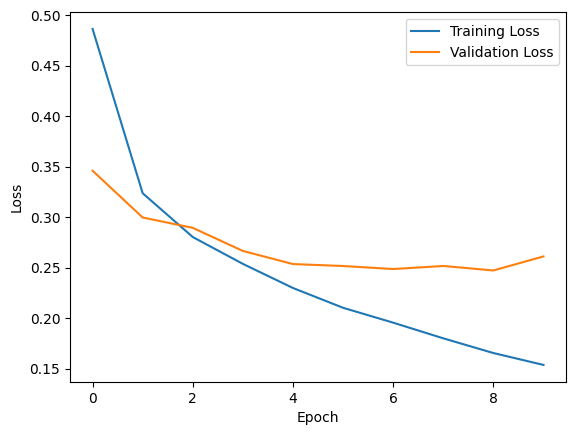

In [ ]:
plt.plot(history.history['loss'],
         label='Training Loss')

plt.plot(history.history['val_loss'],
         label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,104 (2.58 MB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 450,070 (1.72 MB)

Training Accuracy = 94.11%
Validation Accuracy = 91.51%
Difference = 2.6%

The model does not show severe overfitting because the training and validation accuracies are relatively close. The small gap indicates good generalization to unseen data.

1. What kind of patterns do you expect a shallow CNN to learn?

Answer:

A shallow CNN typically learns low-level visual features such as edges, corners, lines, curves, textures, and simple shapes. In the Fashion-MNIST dataset, it may learn features like sleeves, collars, shoe outlines, and bag shapes. These basic features are then combined by later layers to help classify different clothing categories.

2. Did the model show signs of underfitting or overfitting?

Answer:

The model did not show significant signs of either underfitting or overfitting. The final training accuracy was approximately 94.1%, while the validation/test accuracy was approximately 91.5%. Since the gap between training and validation accuracy is small (around 2.6%), the model demonstrates good generalization to unseen data. If the gap had been much larger, it would have indicated overfitting.

#Build and Train a Deep CNN

In [15]:


deep_model = Sequential([

    Conv2D(32, (3,3), activation='relu',
           input_shape=(28,28,1)),

    Conv2D(32, (3,3), activation='relu'),

    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),

    Conv2D(64, (3,3), activation='relu'),

    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),

    Dropout(0.5),

    Dense(10, activation='softmax')
])

In [16]:
deep_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [17]:
history_deep = deep_model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_data=(x_test, y_test)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 157s 83ms/step - accuracy: 0.7948 - loss: 0.5651 - val_accuracy: 0.8493 - val_loss: 0.3871
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 151s 81ms/step - accuracy: 0.8743 - loss: 0.3517 - val_accuracy: 0.8906 - val_loss: 0.2915
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 151s 81ms/step - accuracy: 0.8906 - loss: 0.3009 - val_accuracy: 0.8953 - val_loss: 0.2876
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 153s 82ms/step - accuracy: 0.9017 - loss: 0.2729 - val_accuracy: 0.9075 - val_loss: 0.2583
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 197s 79ms/step - accuracy: 0.9125 - loss: 0.2465 - val_accuracy: 0.9110 - val_loss: 0.2476
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 150s 80ms/step - accuracy: 0.9170 - loss: 0.2290 - val_accuracy: 0.9124 - val_loss: 0.2422
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 200s 79ms/step - accuracy: 0.9246 - loss: 0.2117 - val_accuracy: 0.9141 - val_loss: 0.2541
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 148s 79ms/step - accuracy: 

Final Test Accuracy

In [18]:
test_loss_deep, test_accuracy_deep = deep_model.evaluate(
    x_test,
    y_test
)

print("Deep CNN Test Accuracy:", test_accuracy_deep)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.9219 - loss: 0.2282
Deep CNN Test Accuracy: 0.9218999743461609


PLotting the accuracy of trainining and validation

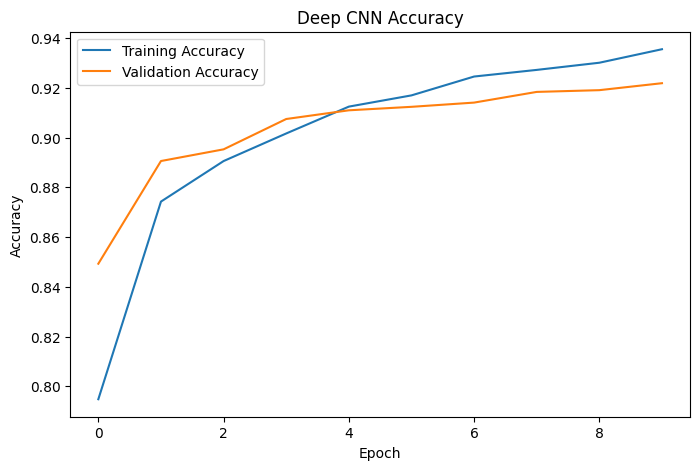

In [19]:
plt.figure(figsize=(8,5))

plt.plot(history_deep.history['accuracy'],
         label='Training Accuracy')

plt.plot(history_deep.history['val_accuracy'],
         label='Validation Accuracy')

plt.title('Deep CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

Training and validation accuracy increased steadily over epochs, indicating that the model successfully learned useful feature representations from the Fashion-MNIST dataset. The validation accuracy remained close to the training accuracy, suggesting good generalization.

Plotting the loss of training and validation

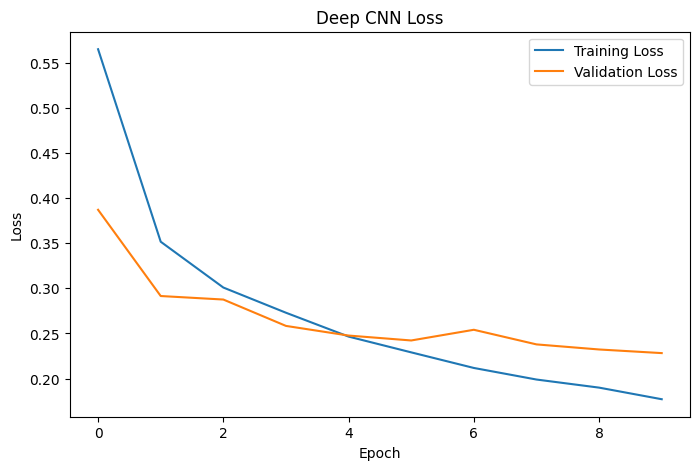

In [20]:
plt.figure(figsize=(8,5))

plt.plot(history_deep.history['loss'],
         label='Training Loss')

plt.plot(history_deep.history['val_loss'],
         label='Validation Loss')

plt.title('Deep CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

Both training loss and validation loss decreased during training, indicating effective learning. Since validation loss did not increase significantly while training loss decreased, the model did not exhibit severe overfitting.

In [26]:
deep_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 10, 10, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 592,448 (2.26 MB)

 Trainable params: 197,482 (771.41 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 394,966 (1.51 MB)

##What additional patterns or representations might a deep CNN learn?

A deep CNN can learn hierarchical feature representations. Initial layers learn basic features such as edges, textures, and curves, while deeper layers combine these features to recognize more complex structures such as sleeves, collars, shoe soles, and bag shapes. This enables the model to better distinguish between visually similar classes.

##Did the deeper model improve performance meaningfully?

Yes, the deeper CNN achieved a test accuracy of 92.19% compared to 91.51% for the shallow CNN. Although the improvement was modest (0.68%), it demonstrates that the additional convolution layers helped the model learn richer feature representations and slightly improve classification performance.

#Part 4: Comparative Study of Shallow CNN vs Deep CNN



| Metric                | Shallow CNN |     Deep CNN |
| --------------------- | ----------: | -----------: |
| Number of Conv Layers |           2 |            4 |
| Total Parameters      |     225,034 |      197,482 |
| Training Accuracy     |      94.11% |       93.56% |
| Validation Accuracy   |      91.51% |       92.19% |
| Test Accuracy         |      91.51% |       92.19% |
| Overfitting Observed? |    Slightly | Very Minimal |
| Training Time         |       Lower |       Higher |


**Which model performed better overall?**

The Deep CNN performed slightly better overall, achieving a test accuracy of 92.19% compared to 91.51% for the Shallow CNN. It also showed slightly better generalization.

**Did the Deep CNN justify its added complexity?**

Yes. Although the improvement in accuracy was modest, the Deep CNN learned richer feature representations and achieved better validation and test performance. The additional complexity helped improve classification quality.

**Which model generalized better?**

The Deep CNN generalized slightly better because the gap between training accuracy and validation accuracy was smaller than that of the Shallow CNN, indicating less overfitting.

**What trade-off did you observe between simplicity and performance?**

The Shallow CNN was simpler and faster to train, while the Deep CNN achieved slightly higher accuracy and better generalization. The trade-off is between computational complexity and predictive performance.

#Part 5: Prediction and Error Analysis

Generating prediction on both models with same data set

In [24]:
y_pred_shallow = model.predict(x_test)
y_pred_shallow_classes = np.argmax(y_pred_shallow, axis=1)

y_pred_deep = deep_model.predict(x_test)
y_pred_deep_classes = np.argmax(y_pred_deep, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step


In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns



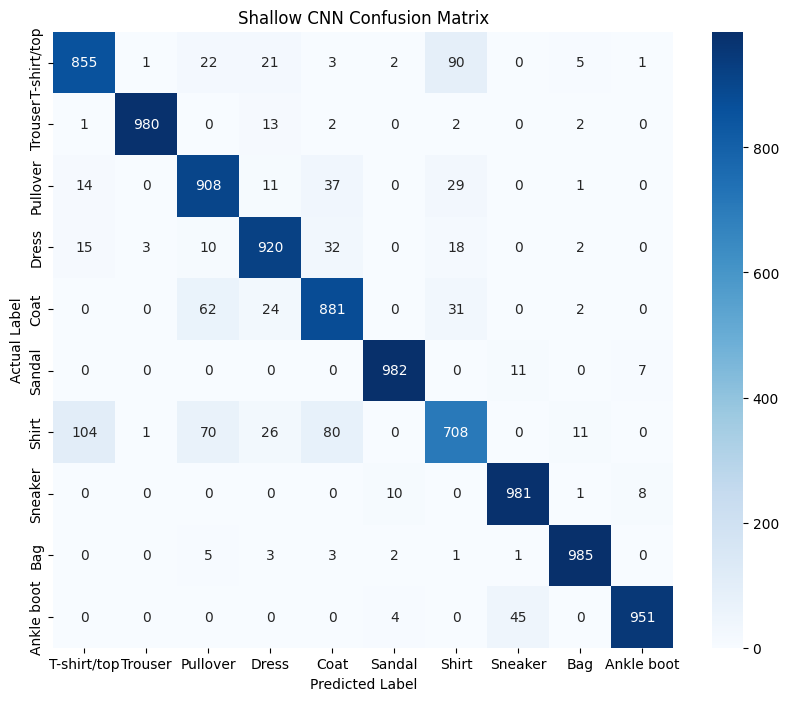

In [28]:

cm_shallow = confusion_matrix(
    y_test,
    y_pred_shallow_classes
)

plt.figure(figsize=(10,8))
sns.heatmap(
    cm_shallow,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Shallow CNN Confusion Matrix")

plt.show()

In this shallow CNN, the test accuracy is 91.5%. As per the confusion matrix you can see the model performs well and predicts Bag-985, Sandal -982,SNeaker 981 and Trouser 980. In this the confusion is happening between Actual shirt-predicted tshirt is 104, actual shirt-predicted pullover 70, actual coat-predicted pullover-62,actual shirt-predicted coat is 80,actual ankle boot-predicted sneaker 45. Looks like the shallow CNN is confused sometimes due to visual appearances of these items.

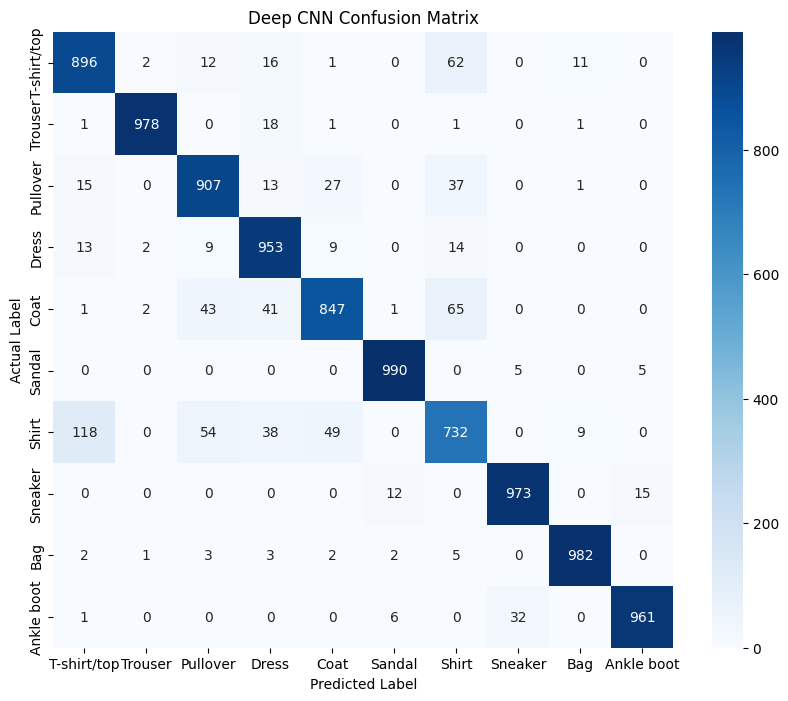

In [29]:
cm_deep = confusion_matrix(
    y_test,
    y_pred_deep_classes
)

plt.figure(figsize=(10,8))
sns.heatmap(
    cm_deep,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Deep CNN Confusion Matrix")

plt.show()

In this deep CNN the testing accuracy is much better than shallow CNN, which is 92.2%. deep CNN predicts well sandal-990,Bag-982,,trouser-978 and sneaker 973. The major confusion here is similar to shallow CNN. Actual shirt-predicted as T-shirt 118 , shirt predicted as pullover 54 times,shirt predicted as coat 49 times, actual coat predicted as shirt 65 times. Actual T shirt as shirt 62 times. THis is also due to the confusion in the visual appearances of these items

| Class       | Shallow CNN (Correct Predictions) | Deep CNN (Correct Predictions) | Improvement |
| ----------- | --------------------------------: | -----------------------------: | ----------- |
| Shirt       |              708 |                            732 | +24        |
| T-shirt/top |              855 |                            896 | +41        |
| Dress       |              920 |                            953 | +33       |



Deep CNN has shown improvements in certain class predictions

5 correctly classified images-Deep CNN

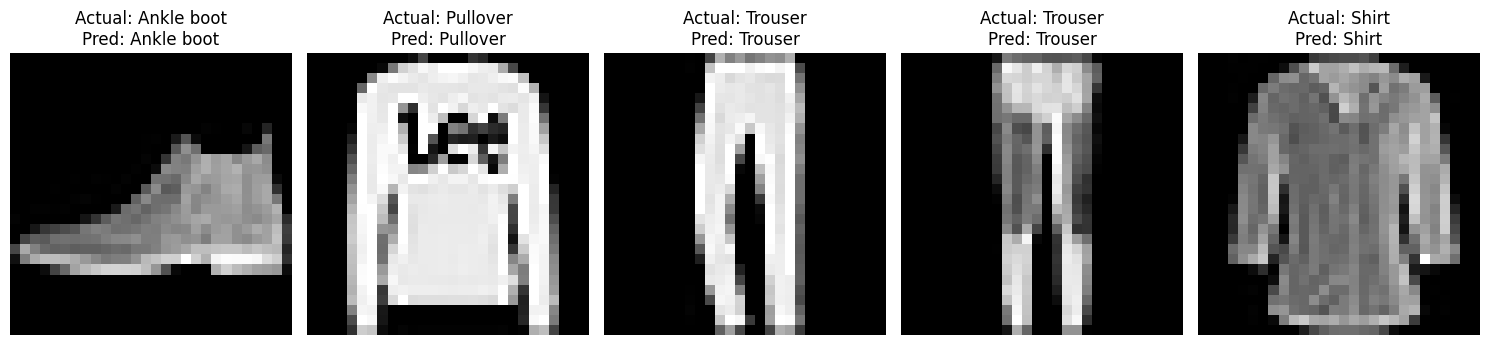

In [30]:
correct_idx = np.where(y_pred_deep_classes == y_test)[0]

plt.figure(figsize=(15,6))

for i in range(5):

    idx = correct_idx[i]

    plt.subplot(1,5,i+1)

    plt.imshow(x_test[idx].reshape(28,28),
               cmap='gray')

    plt.title(
        f"Actual: {class_names[y_test[idx]]}\n"
        f"Pred: {class_names[y_pred_deep_classes[idx]]}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

5 incorrectly classified images-Deep CNN

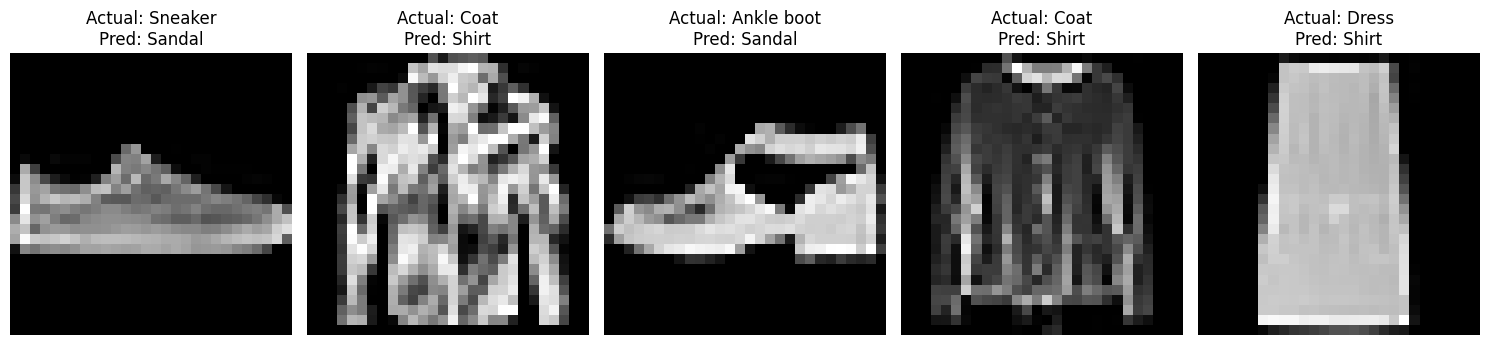

In [31]:
incorrect_idx = np.where(y_pred_deep_classes != y_test)[0]

plt.figure(figsize=(15,6))

for i in range(5):

    idx = incorrect_idx[i]

    plt.subplot(1,5,i+1)

    plt.imshow(x_test[idx].reshape(28,28),
               cmap='gray')

    plt.title(
        f"Actual: {class_names[y_test[idx]]}\n"
        f"Pred: {class_names[y_pred_deep_classes[idx]]}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

5 correctly classified with shallow CNN

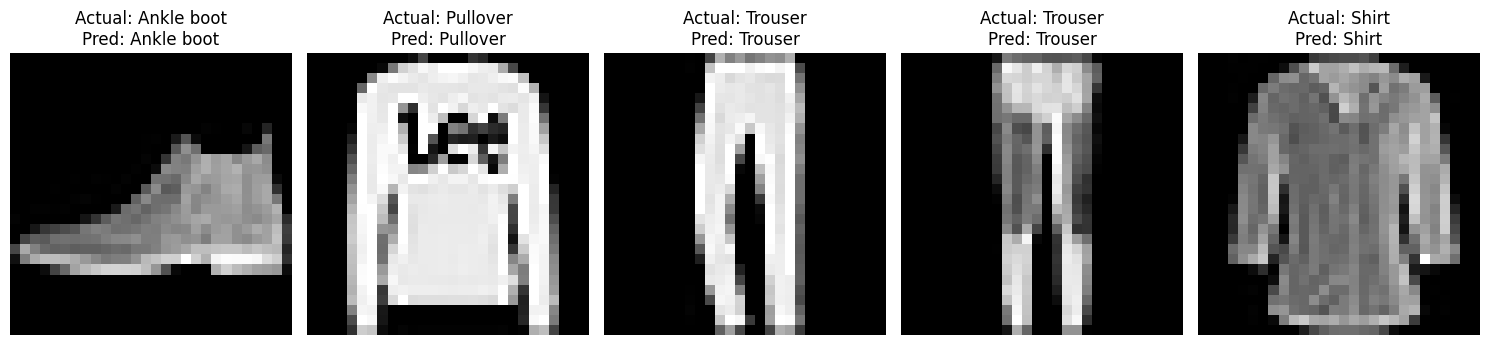

In [32]:
correct_idx_shallow = np.where(
    y_pred_shallow_classes == y_test
)[0]

plt.figure(figsize=(15,6))

for i in range(5):

    idx = correct_idx_shallow[i]

    plt.subplot(1,5,i+1)

    plt.imshow(
        x_test[idx].reshape(28,28),
        cmap='gray'
    )

    plt.title(
        f"Actual: {class_names[y_test[idx]]}\n"
        f"Pred: {class_names[y_pred_shallow_classes[idx]]}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

5 incorrectly classified with SHallow CNN

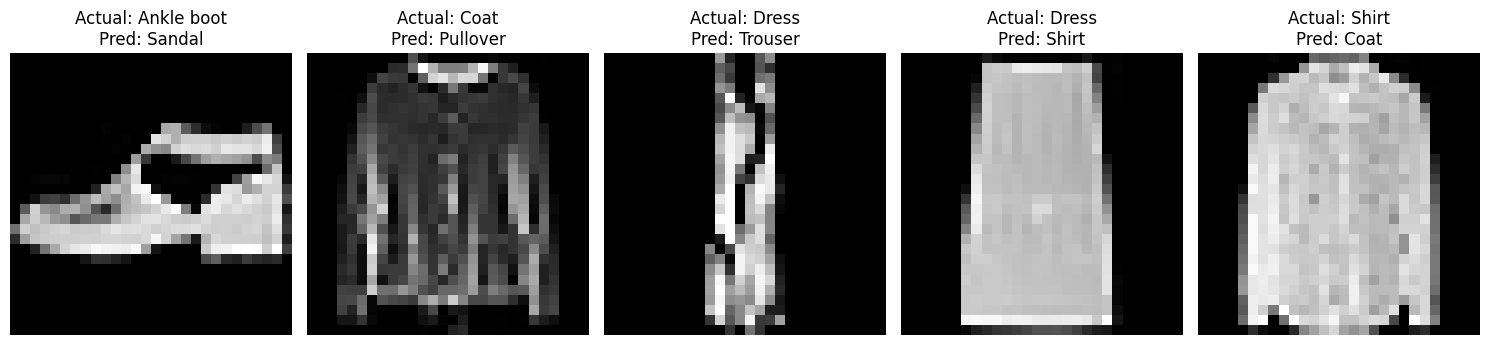

In [33]:
incorrect_idx_shallow = np.where(
    y_pred_shallow_classes != y_test
)[0]

plt.figure(figsize=(15,6))

for i in range(5):

    idx = incorrect_idx_shallow[i]

    plt.subplot(1,5,i+1)

    plt.imshow(
        x_test[idx].reshape(28,28),
        cmap='gray'
    )

    plt.title(
        f"Actual: {class_names[y_test[idx]]}\n"
        f"Pred: {class_names[y_pred_shallow_classes[idx]]}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

##Which classes were easiest to classify?

The models performed very well on classes such as Trouser, Ankle Boot, Sneaker, Bag, and Sandal. These items have distinct shapes and visual characteristics that make them easier to recognize. For example, trousers have a unique long-leg structure, while bags and footwear have shapes that are quite different from clothing items. Because of these clear visual features, both CNN models were able to classify them with high accuracy.

##Which classes were most commonly confused?

The models found it more challenging to distinguish between classes such as Shirt, T-shirt/top, Pullover, Coat, and Dress. These clothing items share similar shapes, sleeves, and overall structure, making them look alike in low-resolution grayscale images. As a result, the models occasionally confused one category with another, especially when the visual differences were subtle.

##Did the Deep CNN reduce confusion between similar-looking classes?

Yes, the Deep CNN was able to reduce some of the confusion between similar-looking classes. Compared to the Shallow CNN, it correctly classified more images of Shirts, T-shirts, and Dresses. This suggests that the additional convolution layers helped the model learn more detailed and meaningful features, allowing it to make better distinctions between categories that look visually similar. Although some confusion still remained, the Deep CNN showed a noticeable improvement in handling these difficult cases.

#Part 6: Final Comparative Conclusion

##Which model would you recommend for Fashion-MNIST?

Based on the results obtained in this study, I would recommend the Deep CNN for the Fashion-MNIST dataset. Although both models performed well, the Deep CNN achieved slightly higher accuracy and was better at distinguishing between similar-looking clothing categories. The improvement was not huge, but it showed that the additional layers helped the model learn more detailed features from the images.

##Which model was more efficient?

The Shallow CNN was more efficient because it had a simpler architecture and trained faster. It required fewer computational resources while still achieving strong performance. This makes it a good choice when training time or computing power is limited.

##Which model was more accurate?

The Deep CNN was the more accurate model in this experiment. It achieved a test accuracy of approximately 92.2%, compared to 91.5% for the Shallow CNN. The deeper architecture was able to learn more complex patterns from the images, which helped improve its prediction performance.

##What did you learn from this comparative study?

This study helped me understand how the depth of a CNN affects its learning capability and performance. I observed that a shallow network can learn basic image features and achieve good results, while a deeper network can capture more complex patterns and improve classification accuracy. I also learned that increasing model complexity does not always lead to a large improvement in performance, especially when working with relatively simple datasets such as Fashion-MNIST. Choosing the right model requires balancing accuracy, training time, and computational cost.


#Short comparative report summarizing objective, dataset overview, model comparison, key observations, and final conclusion.

## Objective

The objective of this assignment was to understand how the depth of a Convolutional Neural Network (CNN) affects its performance on an image classification task. To achieve this, I built and trained both a Shallow CNN and a Deep CNN using the Fashion-MNIST dataset and compared their performance based on accuracy, generalization ability, and prediction behavior.

## Dataset Overview

The Fashion-MNIST dataset consists of 70,000 grayscale images of fashion products belonging to 10 different categories such as T-shirts, Trousers, Dresses, Coats, Sandals, Sneakers, Bags, and Ankle Boots. Each image is of size 28×28 pixels. Before training the models, the images were normalized and reshaped to make them suitable for CNN-based image classification.

## Model Comparison

The Shallow CNN consisted of two convolutional layers followed by pooling, flattening, and dense layers. The Deep CNN contained additional convolutional layers and a more complex feature extraction process.

After training both models on the same dataset, the Shallow CNN achieved a test accuracy of approximately 91.5%, while the Deep CNN achieved approximately 92.2%. Although the improvement was not very large, the Deep CNN consistently performed slightly better on unseen data.

## Key Observations

One interesting observation was that both models performed extremely well on visually distinct categories such as Trousers, Bags, Sandals, Sneakers, and Ankle Boots. These classes have unique shapes, making them easier for the models to identify.

However, both models struggled with categories that looked visually similar, such as Shirts, T-shirts, Pullovers, and Coats. These classes share common features and were responsible for most of the classification errors. The Deep CNN was able to reduce some of this confusion and correctly classify more images from these difficult categories.


## Final Conclusion

Overall, both CNN models performed well on the Fashion-MNIST classification task. The Shallow CNN was simpler, faster to train, and still achieved strong results. The Deep CNN, on the other hand, learned more detailed feature representations and achieved slightly better accuracy and generalization.

If accuracy is the primary goal, I would recommend the Deep CNN because it produced the best overall performance. However, if training speed and simplicity are important considerations, the Shallow CNN remains a very effective choice.

Through this assignment, I gained a practical understanding of how CNNs learn image features, how model depth influences performance, and how to evaluate models using accuracy, confusion matrices, and prediction analysis. Most importantly, I learned that building a deeper model does not automatically guarantee a huge improvement, and the best model is often the one that balances performance, complexity, and efficiency.
